# Fuzzy C-Means - Instacart (extended)


Evaluación del número de clusters y ajuste final del modelo. Se comparan las métricas internas y se analizan los perfiles obtenidos para las configuraciones seleccionadas.


In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from modeling_functions import fuzzy_cmeans_metrics, plot_clustering_metrics, analyze_clusters, fit_clustering_model, save_clustering_metrics
import pandas as pd
import time

## Carga y preparación de los datos


In [3]:
df_scaled = pd.read_csv("../../../scaled_data/instacart_scaled.csv")

In [4]:
# Variables utilizadas para clustering
X = df_scaled.drop(columns=["user_id"], errors="ignore")

## Evaluación del número de clusters


In [5]:
resultados_fuzzy = fuzzy_cmeans_metrics(X)

In [ ]:
tabla_metricas = save_clustering_metrics(
    resultados_fuzzy,
    model_name="fuzzy",
    dataset_name="instacart",
    dataset_version="extended",
)

print("Métricas consolidadas en ../../../results/clustering_metrics.csv")
display(tabla_metricas)

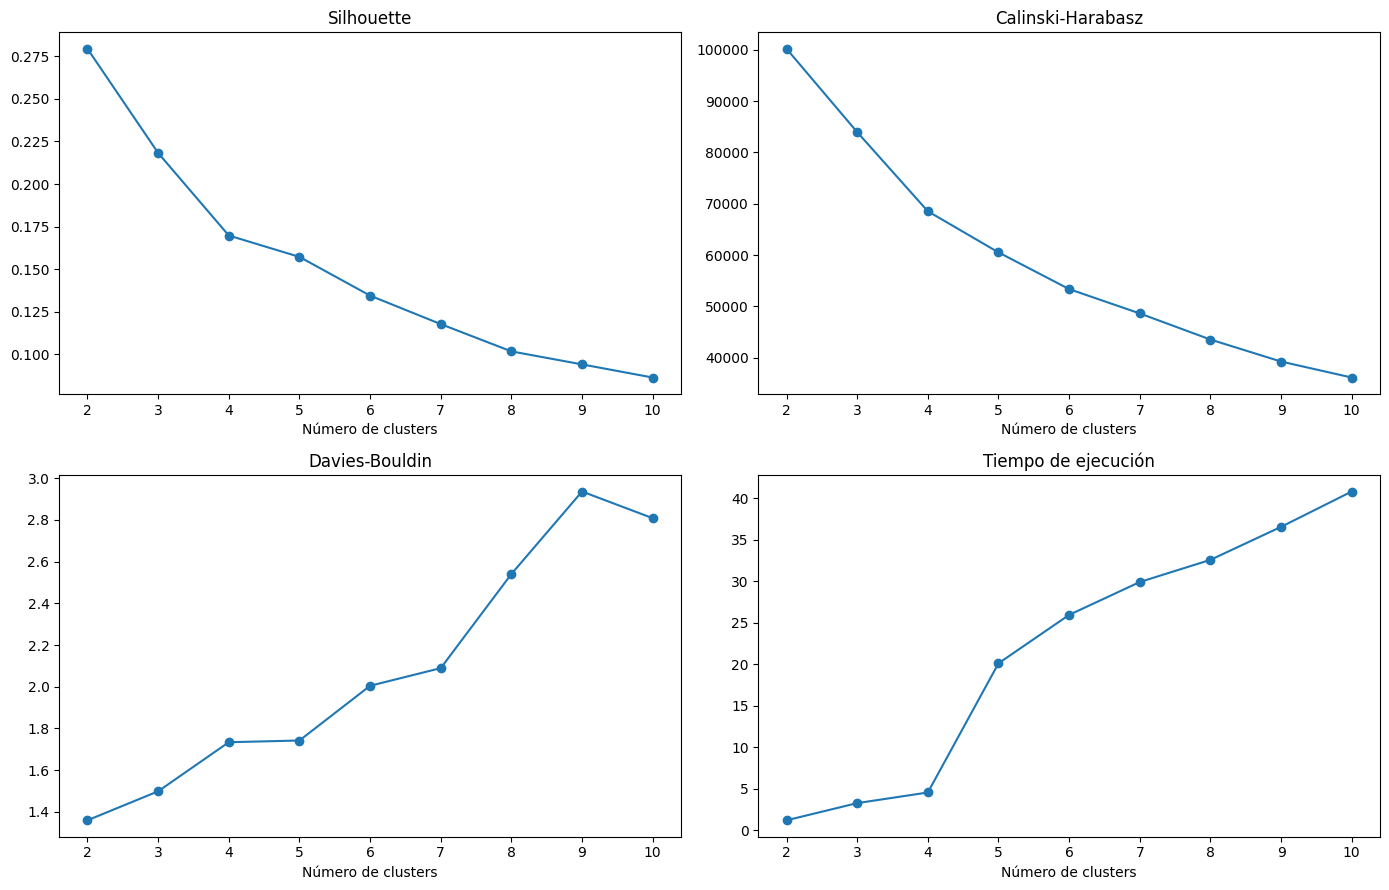

In [6]:
plot_clustering_metrics(resultados_fuzzy)

In [7]:
df_original = pd.read_csv("../../../extended_datasets/instacart_model_extended.csv")

## Ajuste final y perfil de los clusters


In [8]:
modelo, labels = fit_clustering_model(
    model_name="fuzzy",
    k=2,
    X=X
)

cluster_sizes, porcentajes, perfil_clusters, df_clusterizado = analyze_clusters(
    labels,
    df_scaled,
    df_original,
    id_col="user_id"
)

print(f"K-MEANS CON k = {2}")
print("\nTamaño de los clusters:")
display(cluster_sizes)

print("\nPorcentaje de clientes:")
display(porcentajes)

print("\nPerfil medio de los clusters:")
display(perfil_clusters)

K-MEANS CON k = 2

Tamaño de los clusters:


cluster
0    108282
1     97927
Name: count, dtype: int64


Porcentaje de clientes:


cluster
0    52.51
1    47.49
Name: proportion, dtype: float64


Perfil medio de los clusters:


,recency,frequency,avg_basket_size,std_basket_size,avg_days_between_orders,std_days_between_orders,unique_products,unique_aisles,unique_departments,reorder_ratio,product_variety_ratio
cluster,,,,,,,,,,,
0,21.357,6.616,7.913,3.399,16.099,11.442,30.531,17.354,8.562,0.317,0.683
1,12.312,25.514,12.206,5.225,10.475,7.307,102.138,39.317,13.334,0.559,0.441


- Cluster 0 – Clientes ocasionales y de baja vinculación: presentan una recencia elevada, una frecuencia de compra baja y cestas relativamente pequeñas. Compran menos productos distintos, recorren menos pasillos y departamentos y presentan una tasa de recompra reducida. Su elevado product_variety_ratio indica que, dentro de su menor volumen de compra, tienden a repetir menos los mismos productos.
- Cluster 1 – Clientes frecuentes y recurrentes: presentan una recencia menor y una frecuencia de compra muy superior. Realizan cestas más grandes, compran una variedad absoluta mucho mayor de productos, pasillos y departamentos y muestran una tasa de recompra elevada. Representan, por tanto, a los clientes más activos, recurrentes y vinculados con la plataforma.